# Group 46 — Data mining Project 
## From Data to Destinations:Segmenting AIAI’s Customers for Smarter Decisions -Notebook


#### Students :Batoul Abdullah (20250536), Joel Clemen -Holder (20250538), Henrique Joao Monteiro Simoes Alvares Serrao (20250359)

### Data Expolration and Initial Analysis

In [351]:
#importing needed libraries 

In [352]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

In [353]:
#importing the two datasets 

In [354]:
customers = pd.read_csv("DM_AIAI_CustomerDB.csv")
flights = pd.read_csv("DM_AIAI_FlightsDB.csv")

In [355]:
#checking the characteristics of the data

In [356]:
customers.shape

(16921, 21)

In [357]:
flights.shape

(608436, 10)

In [358]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

In [359]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [360]:
#checking the datatypes 

In [361]:
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [362]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

In [363]:
#from the above we decided to change the type of below features to be datetime 

In [541]:
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'], errors='coerce')
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], errors='coerce')

In [542]:
#checking the results

In [543]:
customers.dtypes

Unnamed: 0                          int64
Loyalty#                            int64
First Name                         object
Last Name                          object
Customer Name                      object
Country                            object
Province or State                  object
City                               object
Latitude                          float64
Longitude                         float64
Postal code                        object
Gender                             object
Education                          object
Location Code                      object
Income                            float64
Marital Status                     object
LoyaltyStatus                      object
EnrollmentDateOpening      datetime64[ns]
CancellationDate           datetime64[ns]
Customer Lifetime Value           float64
EnrollmentType                     object
dtype: object

In [544]:
flights.dtypes

Loyalty#                              int64
Year                                  int64
Month                                 int64
YearMonthDate                datetime64[ns]
NumFlights                          float64
NumFlightsWithCompanions            float64
DistanceKM                          float64
PointsAccumulated                   float64
PointsRedeemed                      float64
DollarCostPointsRedeemed            float64
HasFlown                              int64
HasRedeemedPoints                     int64
AverageDistancePerFlight            float64
RedeemRate                          float64
FlightsWithCompanionRatio           float64
dtype: object

In [545]:
#checking the duplicates for both datasets :

In [546]:
customers.duplicated().sum()

np.int64(0)

In [547]:
flights.duplicated().sum()

np.int64(0)

In [548]:
#duplicates dropped

In [549]:
flights.drop_duplicates()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,HasFlown,HasRedeemedPoints,AverageDistancePerFlight,RedeemRate,FlightsWithCompanionRatio
0,413052,2021,12,2021-12-01,2.0,2.0,9384.0,938.00,0.0,0.0,1,0,4692.000000,0.000000,1.0000
1,464105,2021,12,2021-12-01,0.0,0.0,0.0,0.00,0.0,0.0,1,0,NaN,NaN,NaN
2,681785,2021,12,2021-12-01,10.0,3.0,14745.0,1474.00,0.0,0.0,1,0,1474.500000,0.000000,0.3000
3,185013,2021,12,2021-12-01,16.0,4.0,26311.0,2631.00,3213.0,32.0,1,1,1644.437500,1.221209,0.2500
4,216596,2021,12,2021-12-01,9.0,0.0,19275.0,1927.00,0.0,0.0,1,0,2141.666667,0.000000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608431,999902,2019,12,2019-12-01,7.2,0.0,30766.5,3076.65,0.0,0.0,1,0,4273.125000,0.000000,0.0000
608432,999911,2019,12,2019-12-01,0.0,0.0,0.0,0.00,0.0,0.0,1,0,NaN,NaN,NaN
608433,999940,2019,12,2019-12-01,14.4,0.9,18261.0,1826.10,0.0,0.0,1,0,1268.125000,0.000000,0.0625
608434,999982,2019,12,2019-12-01,0.0,0.0,0.0,0.00,0.0,0.0,1,0,NaN,NaN,NaN


In [550]:
flights = flights.drop_duplicates()

In [551]:
#checking the duplicates for #Loyalty as it is the identifier and should not has ducplicates  :

In [552]:
customers['Loyalty#'].duplicated().sum()

np.int64(164)

In [553]:
flights['Loyalty#'].duplicated().sum()

np.int64(588796)

In [554]:
#we identified that , flights dataset has duplications in the #Loyalty  
#FlightsDB is at monthly granularity, so multiple records per customer are expected.
# we have to explore more in case we need to remove them in the next stages

In [555]:
#Showing a summary of all numerical variables in the Datasets :

In [556]:
customers.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,0.0,4210.0,8440.0,12670.0,16900.0,4884.775439
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,100011.0,326823.0,550896.0,772438.0,999999.0,259251.503597
First Name,16921,4941,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,42.984924,44.231171,46.087818,49.28273,60.721188,3.307971
Longitude,16921.0,NaN,NaN,NaN,-91.814768,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.242429


In [557]:
flights.describe(include='all').transpose()

,count,mean,min,25%,50%,75%,max,std
Loyalty#,605533.0,549849.322158,100018.0,326603.0,550575.0,772152.0,999986.0,258966.799122
Year,605533.0,2020.000467,2019.0,2019.0,2020.0,2021.0,2021.0,0.816593
Month,605533.0,6.501362,1.0,4.0,7.0,10.0,12.0,3.451962
YearMonthDate,605533,2020-06-16 07:45:34.429998592,2019-01-01 00:00:00,2019-10-01 00:00:00,2020-07-01 00:00:00,2021-04-01 00:00:00,2021-12-01 00:00:00,NaN
NumFlights,605533.0,3.926843,0.0,0.0,0.9,7.2,21.0,5.062737
NumFlightsWithCompanions,605533.0,0.988662,0.0,0.0,0.0,1.0,11.0,2.007421
DistanceKM,605533.0,7977.403603,0.0,0.0,993.6,15408.9,42040.0,10270.215544
PointsAccumulated,605533.0,797.58325,0.0,0.0,99.0,1540.71,4204.0,1026.897996
PointsRedeemed,605533.0,236.379504,0.0,0.0,0.0,0.0,7496.0,985.452175
DollarCostPointsRedeemed,605533.0,2.335981,0.0,0.0,0.0,0.0,74.0,9.747117


In [558]:
## Showing a summary of all categorical variables in the Dataset :

In [559]:
customers.describe(include=['object']).transpose()

,count,unique,top,freq
First Name,16921,4941,Deon,13
Last Name,16921,15404,Salberg,4
Customer Name,16921,16921,Emma Martin,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [560]:
#Removing columns that are not needed for our analysis in the customer dataset while keeping flights without deleting any 

In [561]:
subset_cols = [
    "Loyalty#","Province or State","City","Latitude","Longitude",
    "Gender","Education","Income","Marital Status","LoyaltyStatus",
    "EnrollmentDateOpening","CancellationDate",'Customer Lifetime Value',"EnrollmentType"
]

In [562]:
#make the subset ONCE using the list

In [563]:
subset_customers = customers.loc[:, subset_cols]

In [564]:
print(subset_customers)

       Loyalty# Province or State          City   Latitude   Longitude  \
0        480934           Ontario       Toronto  43.653225  -79.383186   
1        549612           Alberta      Edmonton  53.544388 -113.490930   
2        429460  British Columbia     Vancouver  49.282730 -123.120740   
3        608370           Ontario       Toronto  43.653225  -79.383186   
4        530508            Quebec          Hull  45.428730  -75.713364   
...         ...               ...           ...        ...         ...   
16916    100012            Quebec   Quebec City  46.759733  -71.141009   
16917    100013           Alberta      Edmonton  53.524829 -113.546357   
16918    100014     New Brunswick       Moncton  46.051866  -64.825428   
16919    100015            Quebec   Quebec City  46.862970  -71.133444   
16920    100016  British Columbia  Dawson Creek  55.720562 -120.160090   

       Gender Education   Income Marital Status LoyaltyStatus  \
0      female  Bachelor  70146.0        Marrie

In [565]:
subset_customers.describe(include=['object']).transpose()

,count,unique,top,freq
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Marital Status,16921,3,Married,9842
LoyaltyStatus,16921,3,Star,7761
EnrollmentType,16921,2,Standard,15773


In [566]:
subset_customers.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,100011.0,326823.0,550896.0,772438.0,999999.0,259251.503597
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,42.984924,44.231171,46.087818,49.28273,60.721188,3.307971
Longitude,16921.0,NaN,NaN,NaN,-91.814768,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.242429
Gender,16921,2,female,8497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,16921,5,Bachelor,10586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,16901.0,NaN,NaN,NaN,37758.0384,0.0,0.0,34161.0,62396.0,99981.0,30368.992499
Marital Status,16921,3,Married,9842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoyaltyStatus,16921,3,Star,7761,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing

In [567]:
#checking the negative values :

In [568]:
numeric_cols = subset_customers.select_dtypes(include='number').columns
negative_summary = (subset_customers[numeric_cols] < 0).sum()
negative_summary = negative_summary[negative_summary > 0]
print("Columns with negative values:")
print(negative_summary)

Columns with negative values:
Longitude    16921
dtype: int64


In [569]:
numeric_cols = flights.select_dtypes(include='number').columns
negative_summary = (flights[numeric_cols] < 0).sum()
negative_summary = negative_summary[negative_summary > 0]
print("Columns with negative values in the Flights dataset:")
print(negative_summary)

Columns with negative values in the Flights dataset:
Series([], dtype: int64)


In [570]:
#there is no negative values in the flights dataset and there is in "Longtitude" which is logical 

In [571]:
#checking the missing values in the customer new subset and the flights dataset:

In [572]:
subset_customers.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Gender                         0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [573]:
flights.isna().sum()

Loyalty#                          0
Year                              0
Month                             0
YearMonthDate                     0
NumFlights                        0
NumFlightsWithCompanions          0
DistanceKM                        0
PointsAccumulated                 0
PointsRedeemed                    0
DollarCostPointsRedeemed          0
HasFlown                          0
HasRedeemedPoints                 0
AverageDistancePerFlight     295720
RedeemRate                   295720
FlightsWithCompanionRatio    301621
dtype: int64

In [574]:
#we noticed that we have missing values in subset_customers dataset at three main variables (Income -CancellationDate -Customer Lifetime Value )
#while there is no missing values in the flights DS

In [575]:
missing_summary = (
    subset_customers.isnull().sum() / len(subset_customers) * 100
).sort_values(ascending=False).to_frame("Missing_Percentage")
print(missing_summary)

                         Missing_Percentage
CancellationDate                  86.360144
Income                             0.118196
Customer Lifetime Value            0.118196
City                               0.000000
Loyalty#                           0.000000
Province or State                  0.000000
Gender                             0.000000
Longitude                          0.000000
Latitude                           0.000000
Education                          0.000000
LoyaltyStatus                      0.000000
Marital Status                     0.000000
EnrollmentDateOpening              0.000000
EnrollmentType                     0.000000


In [576]:
# from checking the missing values percentage above we found that :
# CancellationDate → 86% missing we should keep it and replace it with '00/00/0000' 
#that mean the customer doesn't cancel yet and to keep it the same type as the other values in the same column
# Income → 0.12% missing → to be filled 
# Customer Lifetime Value → 0.12% missing (to be filled )
# Others → no missing values

In [577]:
subset_customers['CancellationDate'] = subset_customers['CancellationDate'].fillna(pd.to_datetime('1900-01-01'))
subset_customers['CancellationDate'].isna().sum()

np.int64(0)

In [578]:
subset_customers.dtypes

Loyalty#                            int64
Province or State                  object
City                               object
Latitude                          float64
Longitude                         float64
Gender                             object
Education                          object
Income                            float64
Marital Status                     object
LoyaltyStatus                      object
EnrollmentDateOpening      datetime64[ns]
CancellationDate           datetime64[ns]
Customer Lifetime Value           float64
EnrollmentType                     object
dtype: object

In [579]:
##we used the histogram to check the distribution of the columns with missing values to decide how to refill it 

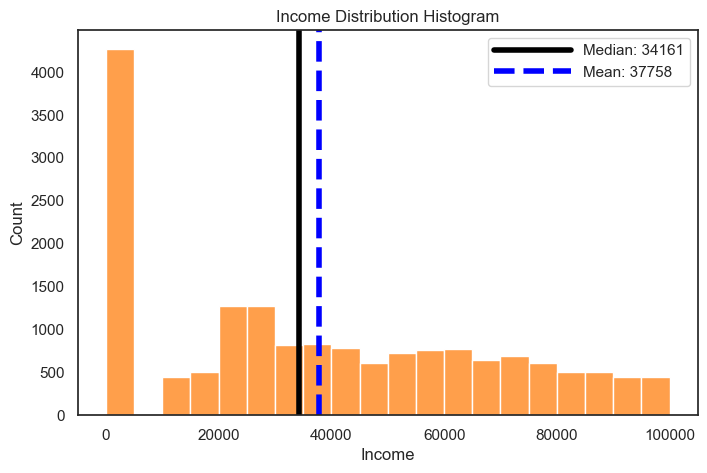

In [580]:
skew_demo = subset_customers["Income"]

# Clean possible strings like "$12,345" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()


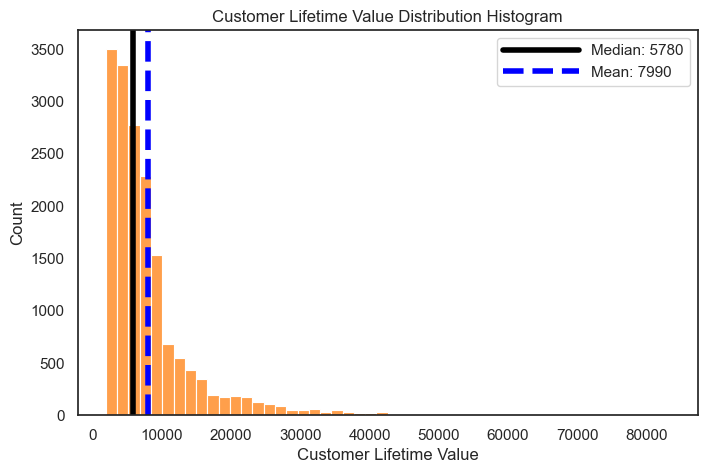

In [581]:
skew_demo = subset_customers["Customer Lifetime Value"]

# Clean possible strings like "$12,345.67" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()


In [582]:
skew_income = subset_customers['Income'].skew()
skew_clv = subset_customers['Customer Lifetime Value'].skew()

print(f"Income: skewness = {skew_income:.2f}")
print(f"Customer Lifetime Value: skewness = {skew_clv:.2f}")

Income: skewness = 0.28
Customer Lifetime Value: skewness = 3.07


In [583]:
# According to the above : we agreed to impute missing values using the median:
# Median is chosen because it is less affected by outliers
# and both Income and Customer Lifetime Value are slightly skewed.

In [584]:
subset_customers['Income'].fillna(subset_customers['Income'].median(), inplace=True)
subset_customers['Customer Lifetime Value'].fillna(subset_customers['Customer Lifetime Value'].median(), inplace=True)
subset_customers[["Income", "Customer Lifetime Value"]].isna().sum()

C:\Users\20250538\AppData\Local\Temp\ipykernel_17540\816792522.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  subset_customers['Income'].fillna(subset_customers['Income'].median(), inplace=True)
C:\Users\20250538\AppData\Local\Temp\ipykernel_17540\816792522.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

Income                     0
Customer Lifetime Value    0
dtype: int64

In [585]:
subset_customers.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

In [586]:
subset_customers.count()

Loyalty#                   16921
Province or State          16921
City                       16921
Latitude                   16921
Longitude                  16921
Gender                     16921
Education                  16921
Income                     16921
Marital Status             16921
LoyaltyStatus              16921
EnrollmentDateOpening      16921
CancellationDate           16921
Customer Lifetime Value    16921
EnrollmentType             16921
dtype: int64

In [587]:
#we are creating a subset which only have peaople who have cancelled so that we can see if there is any significant differences in the distrubution 

In [588]:
subset_non_active = subset_customers[subset_customers["CancellationDate"] != '1900-01-01'].copy()

In [589]:
subset_non_active.shape

(2308, 14)

In [590]:
subset_non_active.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

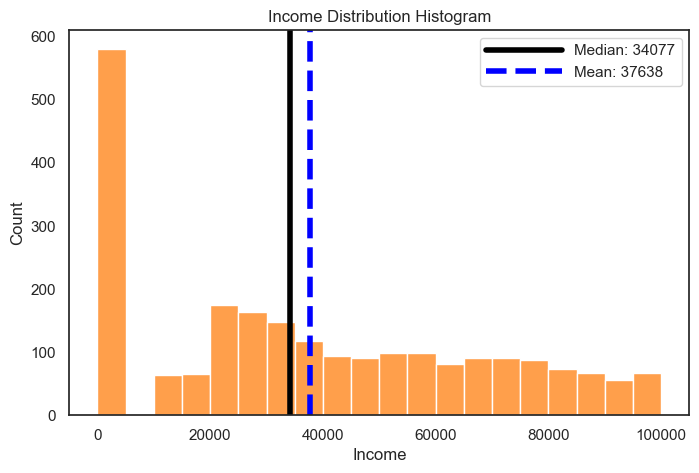

In [591]:
skew_demo = subset_non_active["Income"]

# Clean possible strings like "$12,345" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()


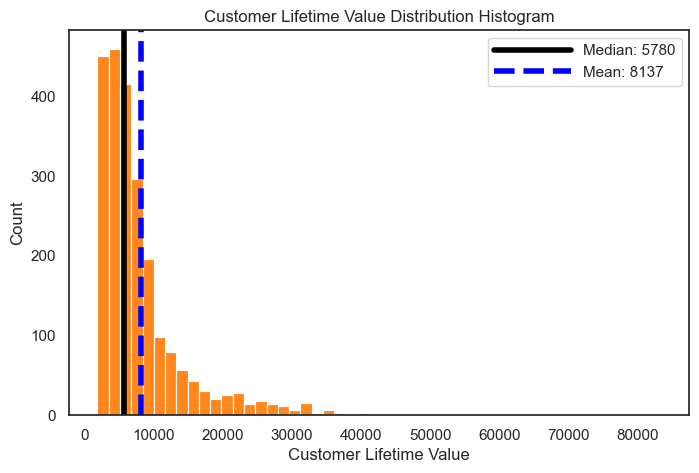

In [592]:
# 1) Build a clean numeric series for Customer Lifetime Value
skew_demo = subset_non_active["Customer Lifetime Value"]

# Clean possible strings like "$12,345.67" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')
sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()


In [593]:
#now we are checking the outliers in the datasets:

In [594]:
subset_customers.select_dtypes(include='number').columns

Index(['Loyalty#', 'Latitude', 'Longitude', 'Income',
       'Customer Lifetime Value'],
      dtype='object')

In [595]:
#creating boxplots for all numeric variables in the subset_customers dataset to visually inspect their distributions and detect possible outliers.

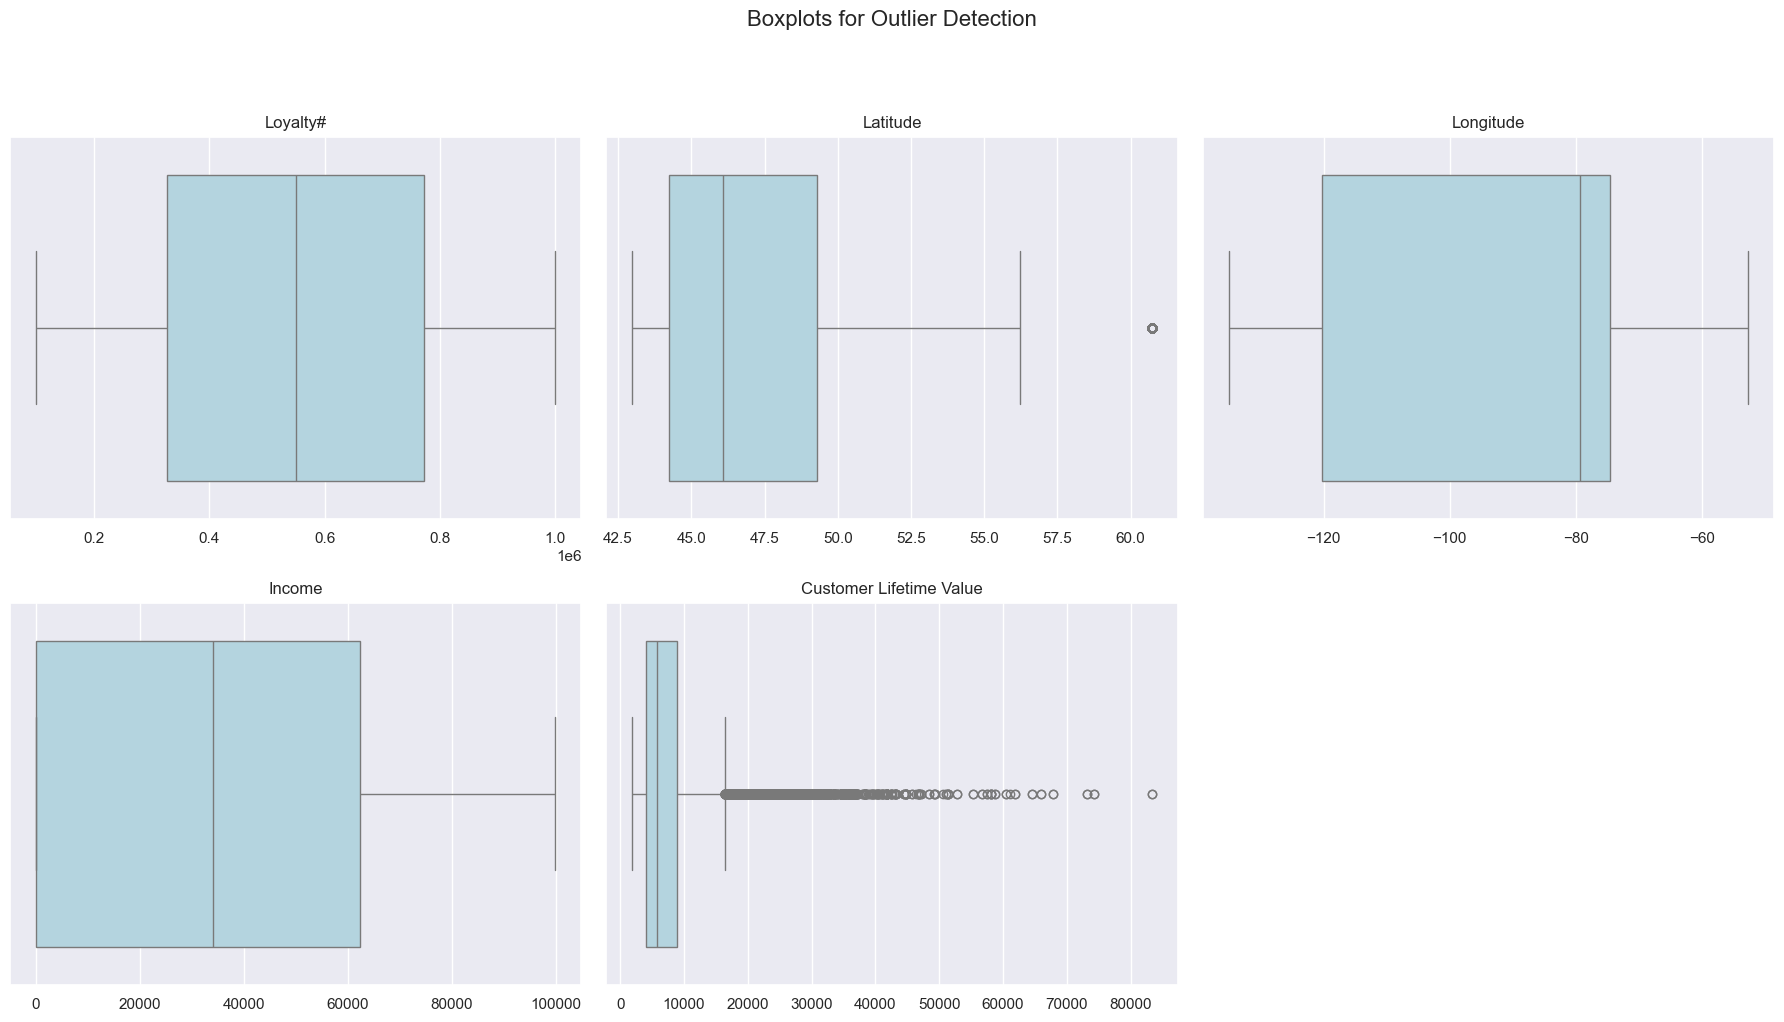

In [596]:
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

num_cols = ['Loyalty#', 'Latitude', 'Longitude', 'Income', 'Customer Lifetime Value']

plt.figure(figsize=(18, 10))
plt.suptitle("Boxplots for Outlier Detection", fontsize=16, y=1.02)

for i, col in enumerate(num_cols, 1):
    plt.subplot(ceil(len(num_cols) / 3), 3, i)
    sns.boxplot(x=subset_customers[col], color='lightblue')
    plt.title(col)
    plt.xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [597]:
filters_man = (
    (subset_customers['Customer Lifetime Value'] <= 60000) 
)

subset_cleaned_manual = subset_customers[filters_man]

# check percentage of data kept
print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_customers.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.9


In [598]:
#We chose this manual filtering method because the boxplot of Customer Lifetime Value (CLV) showed clear extreme outliers.
#A manual threshold of CLV ≤ 60,000 was applied to remove unrealistic values while keeping most valid observations

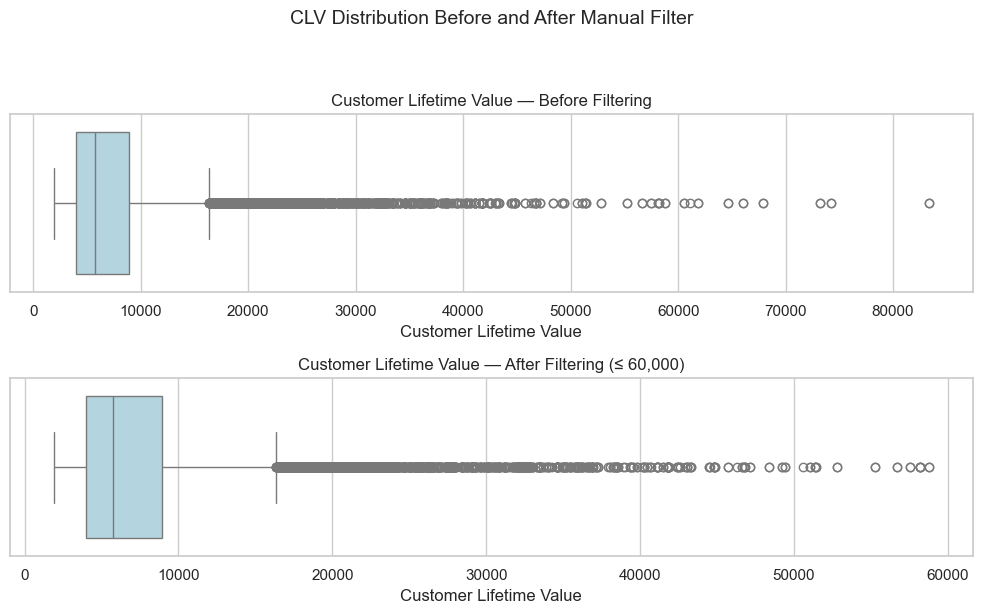

In [599]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharey=True)

sns.boxplot(
    x=subset_customers["Customer Lifetime Value"],
    ax=axes[0],
    color='lightblue'
)
axes[0].set_title("Customer Lifetime Value — Before Filtering")

sns.boxplot(
    x=subset_cleaned_manual["Customer Lifetime Value"],
    ax=axes[1],
    color='lightblue'
)
axes[1].set_title("Customer Lifetime Value — After Filtering (≤ 60,000)")

plt.suptitle("CLV Distribution Before and After Manual Filter", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



In [600]:
#now we are checking the outliers in the flights dataset:

In [601]:
flights.select_dtypes(include='number').columns


Index(['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'AverageDistancePerFlight', 'RedeemRate', 'FlightsWithCompanionRatio'],
      dtype='object')

In [602]:
#creating boxplots for all numeric variables in the Flights dataset to visually inspect their distributions and detect possible outliers.

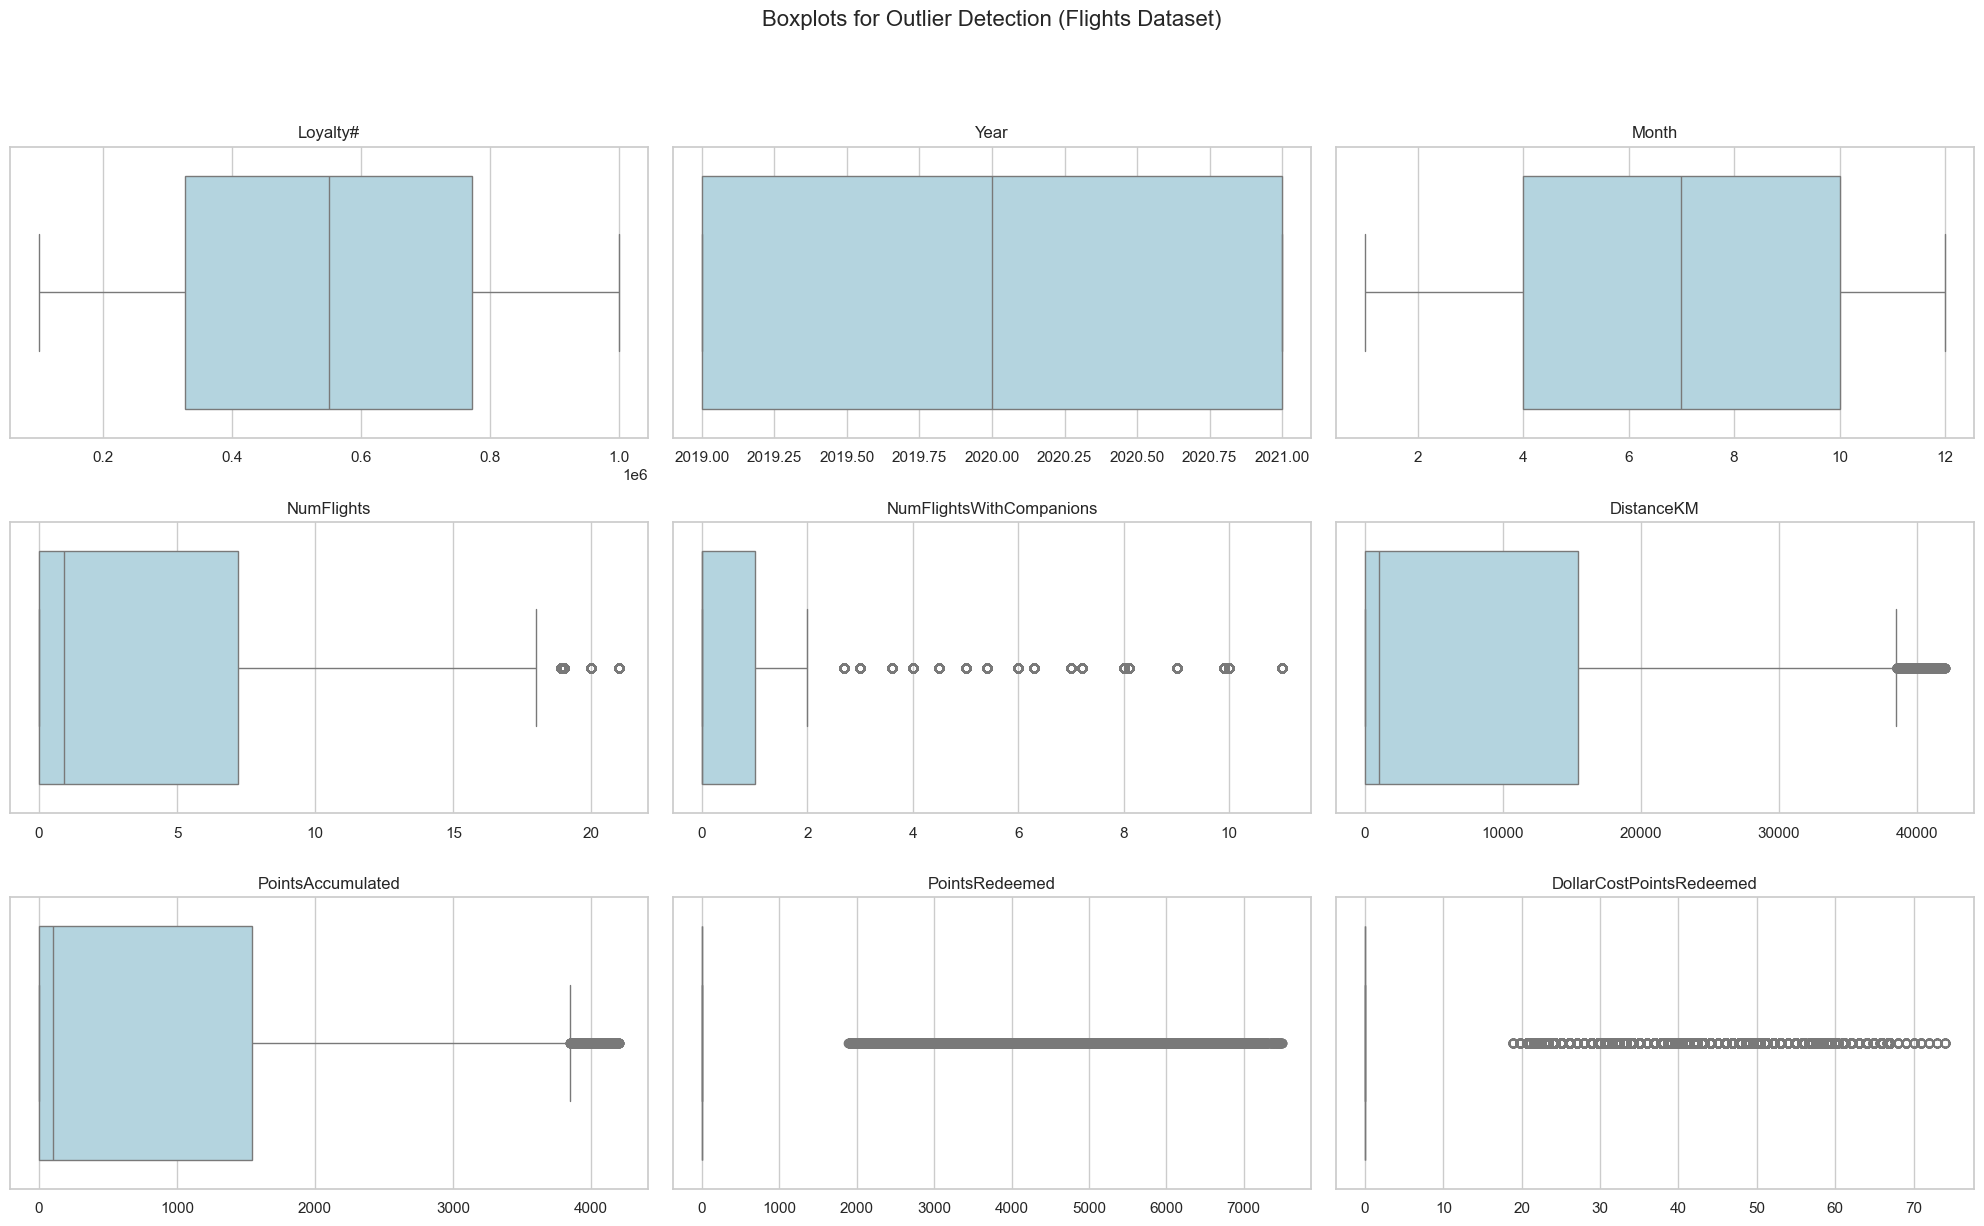

In [603]:
num_cols = ['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
            'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

plt.figure(figsize=(20, 12))
plt.suptitle("Boxplots for Outlier Detection (Flights Dataset)", fontsize=16, y=1.02)

for i, col in enumerate(num_cols, 1):
    plt.subplot(ceil(len(num_cols) / 3), 3, i)
    sns.boxplot(x=flights[col], color='lightblue')
    plt.title(col)
    plt.xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [604]:
#The plots show that variables such as Number of Flights, DistanceKM, and Points Accumulated have several extreme values, while others like Year and Month appear well distributed.

In [605]:
perc_above_8 = (
    (flights["NumFlightsWithCompanions"] > 8).sum() / len(flights)
) * 100

print(f"Percentage of records with NumFlightsWithCompanions > 8: {perc_above_8:.2f}%")

Percentage of records with NumFlightsWithCompanions > 8: 1.08%


In [606]:
flights.count()

Loyalty#                     605533
Year                         605533
Month                        605533
YearMonthDate                605533
NumFlights                   605533
NumFlightsWithCompanions     605533
DistanceKM                   605533
PointsAccumulated            605533
PointsRedeemed               605533
DollarCostPointsRedeemed     605533
HasFlown                     605533
HasRedeemedPoints            605533
AverageDistancePerFlight     309813
RedeemRate                   309813
FlightsWithCompanionRatio    303912
dtype: int64

In [607]:
#Apply IQR method to detect and keep reasonable values

In [608]:
df_original = flights

col = "NumFlightsWithCompanions"
s = df_original[col].dropna()

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
mask_iqr = df_original[col].between(lo, hi, inclusive="both")

mask_manual = df_original[col] <= 8

keep_mask = mask_iqr | mask_manual
df_out = df_original[keep_mask]

print(
    "Percentage of data kept after filtering:",
    np.round(df_out.shape[0] / df_original.shape[0] * 100, 2), "%"
)

Percentage of data kept after filtering: 98.92 %


In [609]:
flights.count()

Loyalty#                     605533
Year                         605533
Month                        605533
YearMonthDate                605533
NumFlights                   605533
NumFlightsWithCompanions     605533
DistanceKM                   605533
PointsAccumulated            605533
PointsRedeemed               605533
DollarCostPointsRedeemed     605533
HasFlown                     605533
HasRedeemedPoints            605533
AverageDistancePerFlight     309813
RedeemRate                   309813
FlightsWithCompanionRatio    303912
dtype: int64

In [610]:
# Use IQR to filter NumFlights

In [611]:

df = flights
metric_features = ["NumFlights"]

# Compute the IQR
q1 = df[metric_features].quantile(.25)

# Calculate Q3
q3 = df[metric_features].quantile(.75)

# Calculate IQR
iqr = (q3 - q1)

# Compute upper and lower limits
lower_lim = q1 - (1.5 * iqr)
upper_lim = q3 + (1.5 * iqr)

filters_iqr = []
for metric in metric_features:
    llim = lower_lim[metric]
    ulim = upper_lim[metric]
    filters_iqr.append(df[metric].between(llim, ulim, inclusive='neither'))

filters_iqr_all = pd.Series(np.all(filters_iqr, 0), index=df.index)

# Apply filter
df_iqr_clean = df[filters_iqr_all]

print('Percentage of data kept after IQR filtering:',
      100 * np.round(df_iqr_clean.shape[0] / df.shape[0], 4))


Percentage of data kept after IQR filtering: 98.86


In [612]:
flights.count()

Loyalty#                     605533
Year                         605533
Month                        605533
YearMonthDate                605533
NumFlights                   605533
NumFlightsWithCompanions     605533
DistanceKM                   605533
PointsAccumulated            605533
PointsRedeemed               605533
DollarCostPointsRedeemed     605533
HasFlown                     605533
HasRedeemedPoints            605533
AverageDistancePerFlight     309813
RedeemRate                   309813
FlightsWithCompanionRatio    303912
dtype: int64

### Feature Engineering 

In [613]:
#Here in order to evaluate customer travel activity by ensuring flight distance data is accurate and consistent,
#identifying how many flights represent real travel versus inactivity.

In [614]:
flights["DistanceKM"] = pd.to_numeric(flights["DistanceKM"], errors="coerce")
print(flights["DistanceKM"].dtype)
print(flights["DistanceKM"].describe())

float64
count    605533.000000
mean       7977.403603
std       10270.215544
min           0.000000
25%           0.000000
50%         993.600000
75%       15408.900000
max       42040.000000
Name: DistanceKM, dtype: float64


In [615]:
# Count and percentage of zeros in DistanceKM
zero_count = (flights["DistanceKM"] == 0).sum()
zero_pct = (flights["DistanceKM"] == 0).mean() * 100

print(f"Number of zeros in DistanceKM: {zero_count}")
print(f"Percentage of zeros: {zero_pct:.2f}%")


Number of zeros in DistanceKM: 295720
Percentage of zeros: 48.84%


In [616]:
#Nearly half of all flight records (49.08%) show a distance of 0 km, meaning many customers had months without any travel activity.

In [617]:
flights.count()


Loyalty#                     605533
Year                         605533
Month                        605533
YearMonthDate                605533
NumFlights                   605533
NumFlightsWithCompanions     605533
DistanceKM                   605533
PointsAccumulated            605533
PointsRedeemed               605533
DollarCostPointsRedeemed     605533
HasFlown                     605533
HasRedeemedPoints            605533
AverageDistancePerFlight     309813
RedeemRate                   309813
FlightsWithCompanionRatio    303912
dtype: int64

In [618]:
flights.isna().sum()

Loyalty#                          0
Year                              0
Month                             0
YearMonthDate                     0
NumFlights                        0
NumFlightsWithCompanions          0
DistanceKM                        0
PointsAccumulated                 0
PointsRedeemed                    0
DollarCostPointsRedeemed          0
HasFlown                          0
HasRedeemedPoints                 0
AverageDistancePerFlight     295720
RedeemRate                   295720
FlightsWithCompanionRatio    301621
dtype: int64

In [619]:
flights["HasFlown"] = flights["DistanceKM"].notna().astype(int)


In [620]:
#Created a box plot to visualize the distribution of DistanceKM for these active customers.


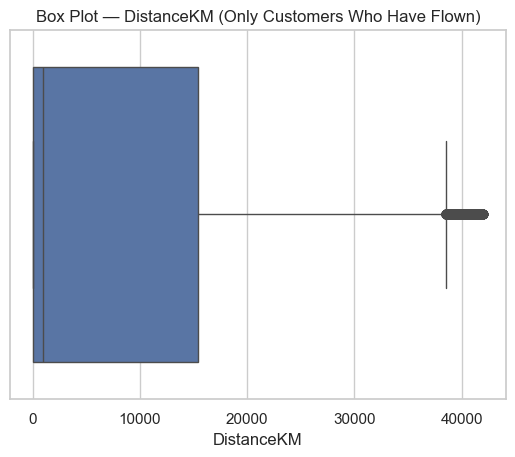

In [621]:
flown_df = flights[flights["HasFlown"] == 1]

# Box plot of DistanceKM for those customers only
sns.boxplot(x=flown_df["DistanceKM"])
plt.title("Box Plot — DistanceKM (Only Customers Who Have Flown)")
plt.show()

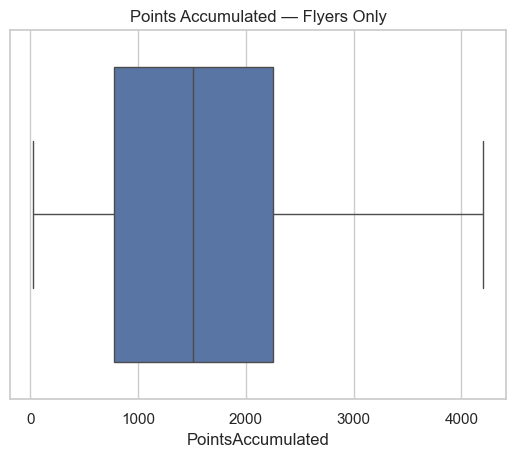

In [622]:
flyers = flights[flights["DistanceKM"].fillna(0) > 0].copy()
sns.boxplot(x=flyers["PointsAccumulated"])
plt.title("Points Accumulated — Flyers Only")
plt.show()

In [623]:
flights["NumFlightsWithCompanions"].value_counts().sort_index()

NumFlightsWithCompanions
0.0     445495
0.9       8368
1.0      17905
1.8       8636
2.0      19272
2.7       8509
3.0      19015
3.6       7138
4.0      13665
4.5       5938
5.0      13424
5.4       5204
6.0       9911
6.3       3508
7.0       7089
7.2       1940
8.0       3965
8.1       1356
9.0       3443
9.9        205
10.0      1071
11.0       476
Name: count, dtype: int64

In [624]:
flights.count()

Loyalty#                     605533
Year                         605533
Month                        605533
YearMonthDate                605533
NumFlights                   605533
NumFlightsWithCompanions     605533
DistanceKM                   605533
PointsAccumulated            605533
PointsRedeemed               605533
DollarCostPointsRedeemed     605533
HasFlown                     605533
HasRedeemedPoints            605533
AverageDistancePerFlight     309813
RedeemRate                   309813
FlightsWithCompanionRatio    303912
dtype: int64

In [625]:
#This visualization identifies how many unique customers traveled from each city

C:\Users\20250538\AppData\Local\Temp\ipykernel_17540\721381556.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


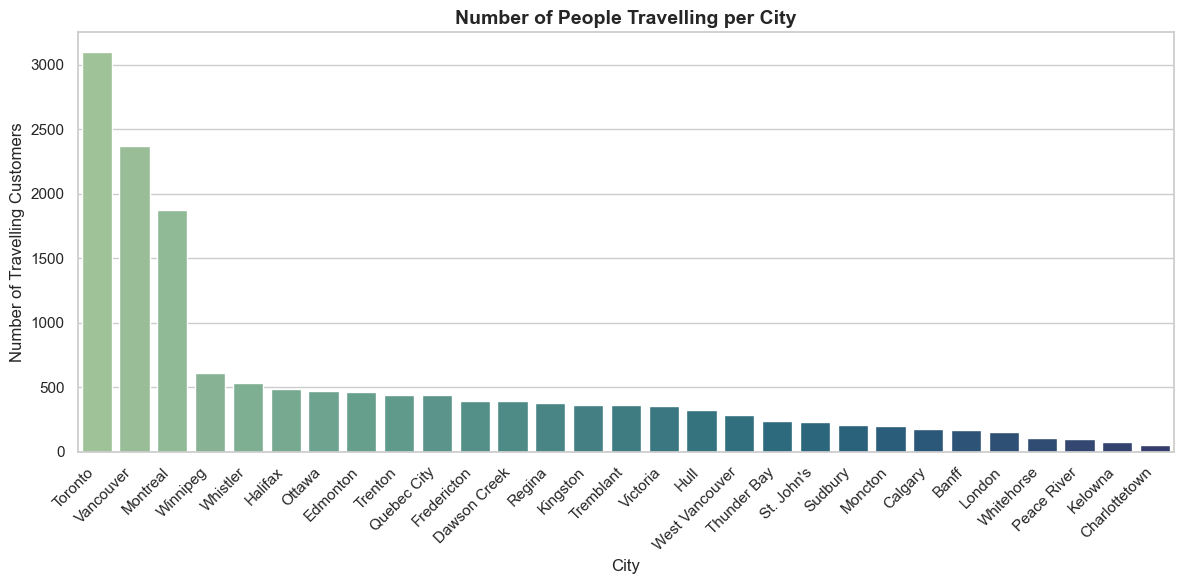

In [626]:

flown_customers = flights[flights["DistanceKM"] > 0]["Loyalty#"].unique()


travelling_customers = subset_customers[subset_customers["Loyalty#"].isin(flown_customers)]


travellers_per_city = (
    travelling_customers.groupby("City")["Loyalty#"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="NumTravellers")
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=travellers_per_city,
    x="City", y="NumTravellers",
    palette="crest"
)

plt.title("Number of People Travelling per City", fontsize=14, weight="bold")
plt.xlabel("City")
plt.ylabel("Number of Travelling Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [627]:
zero_pct = (flights["PointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 points redeemed: 94.16%


In [628]:
# Binary flag for customers who have redeemed points
flights["HasRedeemedPoints"] = (flights["PointsRedeemed"] > 0).astype(int)

# Quick check
flights["HasRedeemedPoints"].value_counts(normalize=True) * 100

HasRedeemedPoints
0    94.155067
1     5.844933
Name: proportion, dtype: float64

In [629]:
zero_pct = (flights["DollarCostPointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 dollar cost points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 dollar cost points redeemed: 94.16%


In [630]:
# Create a new feature (AverageDistancePerFlight) representing the average distance 
# traveled per flight by each customer. This helps identify customers who take 
# short vs. long trips.

In [631]:
flights['AverageDistancePerFlight'] = flights['DistanceKM'] / flights['NumFlights']

In [632]:
# Create a new feature (RedeemRate) that represents the ratio of points redeemed 
# to points accumulated for each customer. This shows how actively customers use 
# their earned points.

In [633]:
flights['RedeemRate'] = flights['PointsRedeemed'] / flights['PointsAccumulated']

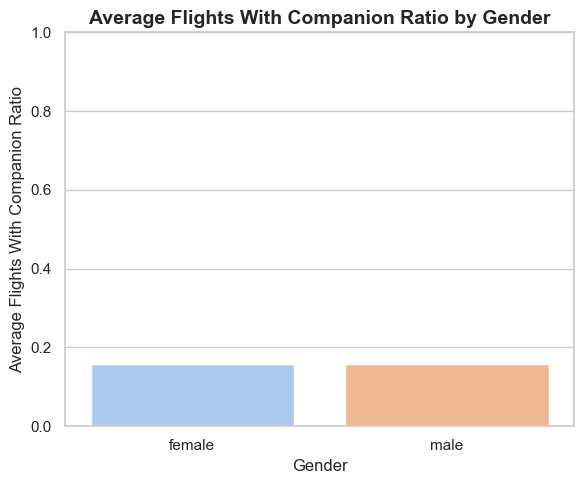

In [634]:
flights["FlightsWithCompanionRatio"] = flights.apply(
    lambda x: x["NumFlightsWithCompanions"] / x["NumFlights"] if x["NumFlights"] > 0 else 0,
    axis=1
)

flights_gender = flights.merge(
    subset_customers[["Loyalty#", "Gender"]],
    on="Loyalty#",
    how="left"
)

avg_ratio_gender = (
    flights_gender.groupby("Gender")["FlightsWithCompanionRatio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))
sns.barplot(
    data=avg_ratio_gender,
    x="Gender",
    y="FlightsWithCompanionRatio",
    hue="Gender",       # <-- added hue
    legend=False,       # <-- hides duplicate legend
    palette="pastel"
)

plt.title("Average Flights With Companion Ratio by Gender", fontsize=14, weight="bold")
plt.xlabel("Gender")
plt.ylabel("Average Flights With Companion Ratio")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [635]:
# Create a new feature (FlightsWithCompanionRatio) representing the proportion of flights
# taken with companions compared to the total number of flights.
# This feature helps identify customers who usually travel alone or with others.

In [636]:
flights['FlightsWithCompanionRatio'] = flights['NumFlightsWithCompanions'] / flights['NumFlights']

In [637]:
flights.head(1)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,HasFlown,HasRedeemedPoints,AverageDistancePerFlight,RedeemRate,FlightsWithCompanionRatio
0,413052,2021,12,2021-12-01,2.0,2.0,9384.0,938.0,0.0,0.0,1,0,4692.0,0.0,1.0


In [638]:
merged = flights.merge(subset_customers, on="Loyalty#", how="right")
merged.head()


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,...,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,2020.0,5.0,2020-05-01,13.0,4.0,25010.0,2501.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
1,480934,2020.0,4.0,2020-04-01,0.0,0.0,5095.0,509.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
2,480934,2020.0,2.0,2020-02-01,3.0,0.0,24271.0,2427.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
3,480934,2020.0,3.0,2020-03-01,0.0,0.0,0.0,0.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
4,480934,2020.0,1.0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard


In [639]:
merged.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,...,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,2020.0,5.0,2020-05-01,13.0,4.0,25010.0,2501.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
1,480934,2020.0,4.0,2020-04-01,0.0,0.0,5095.0,509.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
2,480934,2020.0,2.0,2020-02-01,3.0,0.0,24271.0,2427.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
3,480934,2020.0,3.0,2020-03-01,0.0,0.0,0.0,0.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
4,480934,2020.0,1.0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,...,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard


In [640]:
merged['dollar_redemption_per_flight'] = merged['DollarCostPointsRedeemed'] / merged['NumFlights']

In [641]:
merged['income_points_earned_signal'] = merged['Income'] / merged['PointsAccumulated']

In [642]:
merged['total_flights'] = merged.groupby('Loyalty#')['NumFlights'].transform('sum')

In [643]:
merged = merged.drop(columns=['Year', 'Month'])

In [644]:
merged.head()

,Loyalty#,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,HasFlown,HasRedeemedPoints,...,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,dollar_redemption_per_flight,income_points_earned_signal,total_flights
0,480934,2020-05-01,13.0,4.0,25010.0,2501.0,0.0,0.0,1.0,0.0,...,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,0.0,28.047181,189.6
1,480934,2020-04-01,0.0,0.0,5095.0,509.0,0.0,0.0,1.0,0.0,...,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,NaN,137.811395,189.6
2,480934,2020-02-01,3.0,0.0,24271.0,2427.0,0.0,0.0,1.0,0.0,...,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,0.0,28.902349,189.6
3,480934,2020-03-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,NaN,inf,189.6
4,480934,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,NaN,inf,189.6


In [645]:
merged.columns

Index(['Loyalty#', 'YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'AverageDistancePerFlight', 'RedeemRate', 'FlightsWithCompanionRatio',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Gender',
       'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'EnrollmentType', 'dollar_redemption_per_flight',
       'income_points_earned_signal', 'total_flights'],
      dtype='object')

In [646]:
#NOW I AM THINKING ABOUT WHAT I WILL DROP OF I WILL ENCODE FOR CLUSTERING

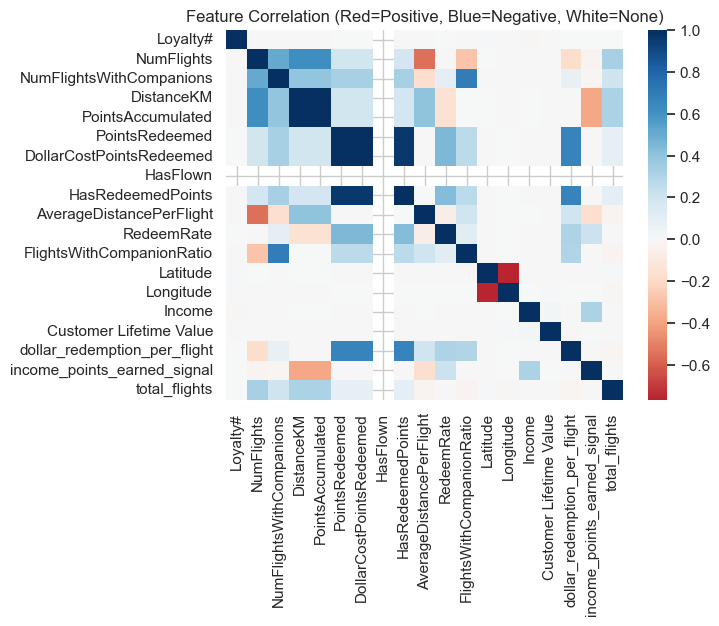

In [647]:
numeric_df = merged.select_dtypes(include=[np.number])  # take only numeric features
corr = numeric_df.corr()

plt.figure()
sns.heatmap(corr, center=0, cmap="RdBu", annot=False)
plt.title("Feature Correlation (Red=Positive, Blue=Negative, White=None)")
plt.show()



In [648]:
merged = merged.drop(columns=['income_points_earned_signal'])

In [649]:
merged = merged.drop(columns=['Loyalty#'])

In [650]:
merged = merged.drop(columns=['Latitude'])


In [651]:
merged = merged.drop(columns=['City'])


In [652]:
merged = merged.drop(columns=['Longitude'])

In [653]:
merged = merged.drop(columns=['Province or State'])

In [654]:
merged.columns

Index(['YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
       'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed',
       'HasFlown', 'HasRedeemedPoints', 'AverageDistancePerFlight',
       'RedeemRate', 'FlightsWithCompanionRatio', 'Gender', 'Education',
       'Income', 'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType',
       'dollar_redemption_per_flight', 'total_flights'],
      dtype='object')

In [656]:
merged = merged.drop(columns=[
    'AverageDistancePerFlight',
    'total_flights',                 
    'DollarCostPointsRedeemed',                      
    'RedeemRate',                 
    'FlightsWithCompanionRatio'       
], errors='ignore')


In [657]:
merged.columns

Index(['YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
       'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'EnrollmentType', 'dollar_redemption_per_flight'],
      dtype='object')

In [658]:
cols_to_drop = [
    'EnrollmentDateOpening',
    'CancellationDate',
    'YearMonthDate',
    'Year',
    'Month'
]

merged = merged.drop(columns=[c for c in cols_to_drop if c in merged.columns])



In [659]:
merged.columns

Index(['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
       'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'Customer Lifetime Value', 'EnrollmentType',
       'dollar_redemption_per_flight'],
      dtype='object')

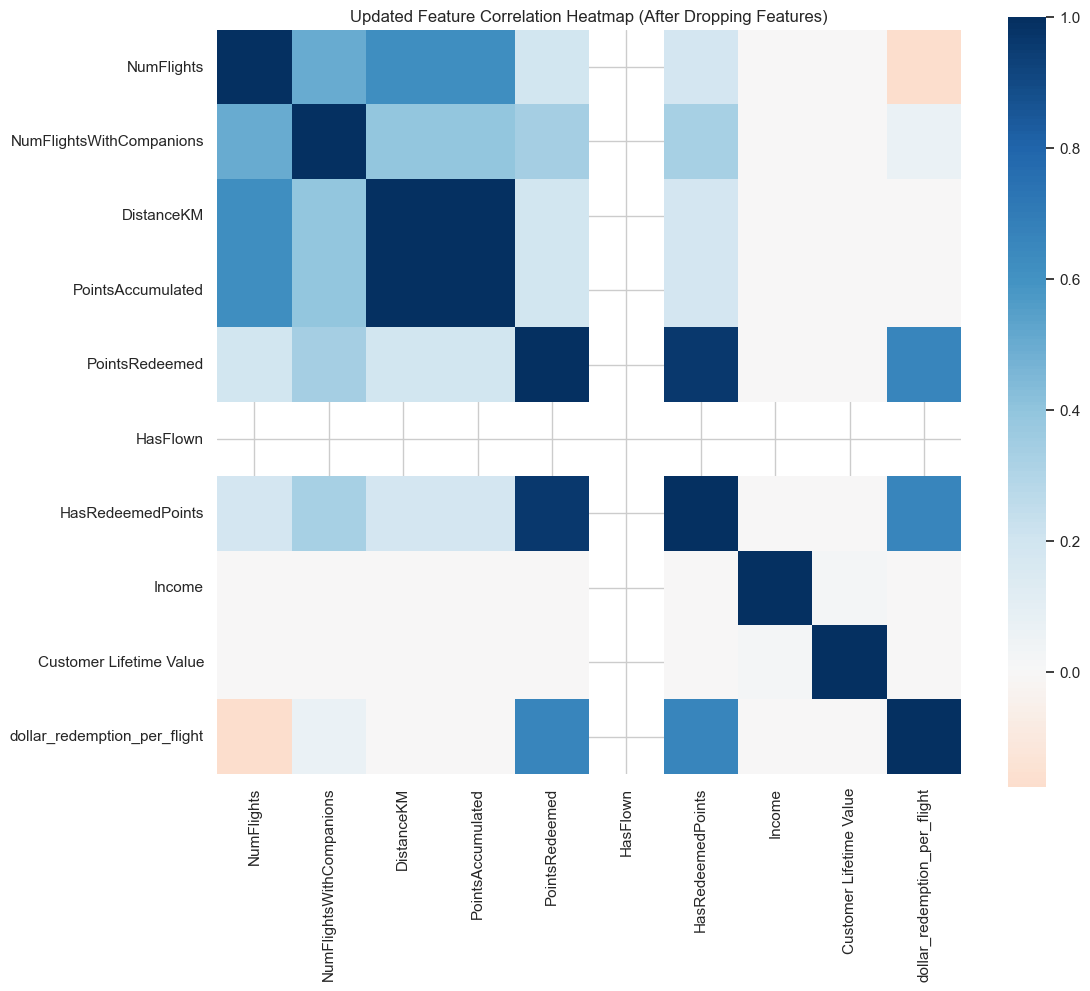

In [660]:
numeric_df = merged.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="RdBu",       # red = high positive, blue = high negative
    center=0,
    annot=False,
    square=True
)

plt.title("Updated Feature Correlation Heatmap (After Dropping Features)")
plt.show()


In [661]:
merged.columns


Index(['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
       'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'Customer Lifetime Value', 'EnrollmentType',
       'dollar_redemption_per_flight'],
      dtype='object')

In [662]:
#ENCODING

In [663]:
merged = pd.get_dummies(
    merged,
    columns=['Gender', 'Marital Status'],
    drop_first=True
)

In [664]:
loyalty_map = {
    'Aurora': 1,
    'Nova': 2,
    'Star': 3
}

merged['LoyaltyStatus'] = merged['LoyaltyStatus'].map(loyalty_map)


In [665]:
merged['Education'].unique()


array(['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor'],
      dtype=object)

In [666]:
education_map = {
    'High School or Below': 1,
    'College': 2,
    'Bachelor': 3,
    'Master': 4,
    'Doctor': 5
}

merged['Education'] = merged['Education'].map(education_map)


In [667]:
merged.columns

Index(['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
       'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'Education', 'Income', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'dollar_redemption_per_flight', 'Gender_male',
       'Marital Status_Married', 'Marital Status_Single'],
      dtype='object')

In [668]:
merged.head()

,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,HasFlown,HasRedeemedPoints,Education,Income,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,dollar_redemption_per_flight,Gender_male,Marital Status_Married,Marital Status_Single
0,13.0,4.0,25010.0,2501.0,0.0,1.0,0.0,3,70146.0,3,3839.14,Standard,0.0,False,True,False
1,0.0,0.0,5095.0,509.0,0.0,1.0,0.0,3,70146.0,3,3839.14,Standard,NaN,False,True,False
2,3.0,0.0,24271.0,2427.0,0.0,1.0,0.0,3,70146.0,3,3839.14,Standard,0.0,False,True,False
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3,70146.0,3,3839.14,Standard,NaN,False,True,False
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3,70146.0,3,3839.14,Standard,NaN,False,True,False


In [669]:
merged = pd.get_dummies(
    merged,
    columns=['EnrollmentType'],
    drop_first=True
)


In [670]:
#SCALING

In [671]:
merged_standard = merged.copy()


In [672]:
merged_standard.columns

Index(['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
       'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints',
       'Education', 'Income', 'LoyaltyStatus', 'Customer Lifetime Value',
       'dollar_redemption_per_flight', 'Gender_male', 'Marital Status_Married',
       'Marital Status_Single', 'EnrollmentType_Standard'],
      dtype='object')

In [673]:
metric_features = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'Income',
    'Customer Lifetime Value'
]

In [674]:
merged_standard[metric_features].describe(include='all')
merged_standard[metric_features].isna().sum()


NumFlights                  20
NumFlightsWithCompanions    20
DistanceKM                  20
PointsAccumulated           20
PointsRedeemed              20
Income                       0
Customer Lifetime Value      0
dtype: int64

In [675]:
print(merged_standard.columns.tolist())


['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints', 'Education', 'Income', 'LoyaltyStatus', 'Customer Lifetime Value', 'dollar_redemption_per_flight', 'Gender_male', 'Marital Status_Married', 'Marital Status_Single', 'EnrollmentType_Standard']


In [676]:
merged_standard['NumFlights'] = merged_standard['NumFlights'].fillna(merged_standard['NumFlights'].median())
merged_standard['DistanceKM'] = merged_standard['DistanceKM'].fillna(merged_standard['DistanceKM'].median())
merged_standard['PointsAccumulated'] = merged_standard['PointsAccumulated'].fillna(merged_standard['PointsAccumulated'].median())


In [677]:
cols_to_fill = [
    'NumFlightsWithCompanions',
    'PointsRedeemed',
    'HasFlown',
    'HasRedeemedPoints'
]

for col in cols_to_fill:
    merged_standard[col] = merged_standard[col].fillna(merged_standard[col].median())


In [678]:
merged_standard.isna().sum()


NumFlights                           0
NumFlightsWithCompanions             0
DistanceKM                           0
PointsAccumulated                    0
PointsRedeemed                       0
HasFlown                             0
HasRedeemedPoints                    0
Education                            0
Income                               0
LoyaltyStatus                        0
Customer Lifetime Value              0
dollar_redemption_per_flight    305977
Gender_male                          0
Marital Status_Married               0
Marital Status_Single                0
EnrollmentType_Standard              0
dtype: int64

In [684]:
merged_standard = merged_standard.drop(columns=['dollar_redemption_per_flight'], errors='ignore')


In [685]:
merged_standard.isna().sum()

NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
HasFlown                    0
HasRedeemedPoints           0
Education                   0
Income                      0
LoyaltyStatus               0
Customer Lifetime Value     0
Gender_male                 0
Marital Status_Married      0
Marital Status_Single       0
EnrollmentType_Standard     0
dtype: int64

In [686]:
print(merged.columns.tolist())


['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'HasFlown', 'HasRedeemedPoints', 'Education', 'Income', 'LoyaltyStatus', 'Customer Lifetime Value', 'Gender_male', 'Marital Status_Married', 'Marital Status_Single', 'EnrollmentType_Standard']


In [687]:
numeric_features = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'HasFlown',
    'HasRedeemedPoints',
    'Education',
    'Income',
    'LoyaltyStatus',
    'Customer Lifetime Value'
]


In [688]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_metrics = scaler.fit_transform(merged_standard[metric_features])

scaled_metrics_df = pd.DataFrame(
    scaled_metrics,
    columns=metric_features,
    index=merged_standard.index
)


In [690]:
# final_df = scaled metrics + all non-metric columns
final_df = pd.concat([
    scaled_metrics_df, 
    merged_standard.drop(columns=metric_features)
], axis=1)
